# LOADING LIBRARIES

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# LOADING DATASET

In [2]:
# # downloading the images

# !wget https://challengedata.ens.fr/media/public/train-images.zip
# !wget https://challengedata.ens.fr/media/public/test-images.zip
# !wget https://challengedata.ens.fr/media/public/label_Hnl61pT.csv -O y_train.csv

In [3]:
# !unzip train-images.zip
# !unzip test-images.zip

In [4]:
def load_dataset(dataset_dir):
    dataset_list = []
    # Note: It's very important to load the images in the correct numerical order!
    for image_file in list(sorted(Path(dataset_dir).glob("*.png"), key=lambda filename: int(filename.name.rstrip(".png")))):
        dataset_list.append(cv2.imread(str(image_file), cv2.IMREAD_GRAYSCALE))
    return np.stack(dataset_list, axis=0)

# Here is a function to display side by side a slide and a segmented mask
def plot_slice_seg(slice_image, seg):
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(slice_image, cmap="gray")
    axes[1].imshow(slice_image, cmap="gray")
    seg_masked = np.ma.masked_where(seg.reshape((256,256)) == 0, (seg.reshape((256,256))))
    axes[1].imshow(seg_masked, cmap="tab20")
    plt.axis("off")
    plt.show()

In [5]:
# Read the data and keep first 800 rows
labels = pd.read_csv('y_train.csv', index_col=0).T.iloc[:800]

# Create a new DataFrame with unique values and their counts for each row
result = labels.apply(
    lambda row: pd.Series({
        'num_unique': len(row.unique())
    }),
    axis=1
)

condition = result['num_unique'].apply(lambda x: x > 1)
labels_train = labels[condition]
# Alternative en une ligne
labeled_indices_array = np.where(condition)[0]

Our dataset images shape is torch.Size([759, 1, 256, 256])
Our dataset labels shape is torch.Size([759, 256, 256])


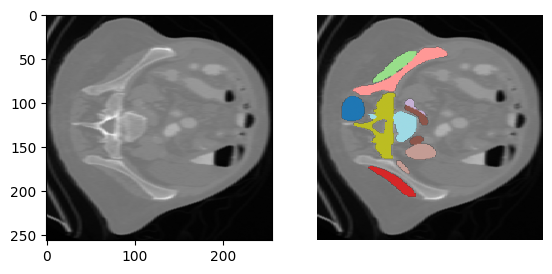

In [6]:
data_dir = Path("./")
data_train = load_dataset(data_dir / "train-images")
data_test = load_dataset(data_dir / "test-images")

## PREPROCESSING
## MIN MAX NORMALIZATION
# data_train = (data_train - np.min(data_train)) / (np.max(data_train) - np.min(data_train))
# data_test = (data_test - np.min(data_test)) / (np.max(data_test) - np.min(data_test))

## STANDARDIZATION
mean, std = data_train.mean(), data_train.std()
data_train = (data_train - mean) / (std + 1e-8)

mean, std = data_test.mean(), data_test.std()
data_test = (data_test - mean) / (std + 1e-8)


data_train_labeled = torch.from_numpy(data_train[labeled_indices_array]).type(torch.float32).reshape((-1, 1, 256,256))
data_test = torch.from_numpy(data_test).type(torch.float32).reshape((-1, 1, 256,256))
labels_train = torch.from_numpy(labels_train.to_numpy()).reshape((-1, 256,256))

print(f"Our dataset images shape is {data_train_labeled.shape}")
print(f"Our dataset labels shape is {labels_train.shape}")
plot_slice_seg(data_train_labeled[5].squeeze(), labels_train[5].squeeze())

In [7]:
## Split for train and test data
X_train, X_valid, y_train, y_valid = train_test_split(data_train_labeled, labels_train, test_size=0.02, random_state=0)
assert len(X_train) == len(y_train)
assert len(X_valid) == len(y_valid)
print(f"Number of training images {len(X_train)}")
print(f"Number of validation images {len(X_valid)}")

Number of training images 743
Number of validation images 16


In [8]:
#construction the data loaders
from torch.utils.data import TensorDataset
BATCH_SIZE = 16
train_ds = TensorDataset(
    X_train.cuda(),
    y_train.cuda(),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_ds = TensorDataset(
    X_valid.cuda(),
    y_valid.cuda(),
)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
# train_loader = DataLoader(list(zip(X_train, y_train)), batch_size=1, shuffle=True)
# valid_loader = DataLoader(list(zip(X_valid, y_valid)), batch_size=1, shuffle=False)

dir_checkpoint = Path('./checkpoints/')

# Swin -UNET

In [9]:
# ! pip install monai timm

In [10]:
## Elementary function to test UNET

def dice_image(prediction, ground_truth):
    intersection = np.sum(prediction * ground_truth)
    if np.sum(prediction) == 0 and np.sum(ground_truth) == 0:
        return np.nan
    return 2 * intersection / (np.sum(prediction) + np.sum(ground_truth))


def dice_multiclass(prediction, ground_truth):
    dices = []
    for i in range(1, NUM_CLASSES + 1): # skip background
        dices.append(dice_image(prediction == i, ground_truth == i))
    return np.array(dices)

def dice_pandas(y_true_df: pd.DataFrame, y_pred_df: pd.DataFrame) -> float:
    """Compute the dice score for each sample in the dataset and then average it"""
    y_pred_df = y_pred_df.T
    y_true_df = y_true_df.T
    individual_dice = []
    for row_index in range(y_true_df.values.shape[0]):
        dices = dice_multiclass(y_true_df.values[row_index].ravel(), y_pred_df.values[row_index].ravel())
        individual_dice.append(dices)

    final = np.stack(individual_dice)
    # First, average over images for each class
    # Then, average over classes
    cls_dices = np.nanmean(final, axis=0)
    return float(np.nanmean(cls_dices))

In [11]:
def dice_loss(pred, target, smooth=1e-7):

    pred = torch.softmax(pred, dim=1)
    target_onehot = torch.nn.functional.one_hot(target, num_classes=pred.shape[1]).permute(0, 3, 1, 2)
    intersection = (pred * target_onehot).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target_onehot.sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

In [ ]:
from time import time
from tqdm.notebook import tqdm

def train_unet(model, device, train_loader, valid_loader, labels_weights, nb_epochs, save_checkpoint=True) :

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    labels_weights = labels_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=labels_weights)
    model = model.to(device)

    for epoch in range(nb_epochs) :

        model.train()
        train_loss = 0

        for (image, mask) in tqdm(train_loader, "training") :

            image = image.to(device=device)
            mask = mask.to(device=device)
            optimizer.zero_grad()
            output = model(image)
            loss_ce = criterion(output, mask)
            loss_dice = dice_loss(output, mask)
            loss = 0.5 * loss_dice + 0.5 * loss_ce
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # for name, param in model.named_parameters():
            #   if param.grad is not None and torch.isnan(param.grad).any():
            #       print(f"NaN gradient in {name}")
            #       return "Stooooop"

            optimizer.step()
            train_loss += loss.item()

        with torch.no_grad() :
            model.eval()
            test_loss = 0
            predictions = []
            true_masks = []

            for (image, mask) in tqdm(valid_loader, desc="evaluating") :
                true_masks.append(mask.cpu().numpy().squeeze())
                image = image.to(device=device)
                mask = mask.to(device=device)

                output = model(image)

                pred = torch.argmax(output, dim=1)
                predictions.append(pred.squeeze().cpu().numpy())

                loss_ce = criterion(output, mask)
                loss_dice = dice_loss(output, mask)
                loss = 0.5 * loss_dice + 0.5 * loss_ce

                test_loss += loss.item()

            mk_df_start_time = time()
            predictions = pd.DataFrame(np.array(predictions).reshape((-1, 256*256)))
            valid = pd.DataFrame(np.array(true_masks).reshape((-1, 256*256)))
            print(f"Time to make DFs:{(time() - mk_df_start_time):.2f}")
            score_compute_start_time = time()
            score = dice_pandas(valid, predictions)
            print(f"Time to compute score: {score_compute_start_time:.2f}")

        print(f"Epoch : {epoch} \t Training Loss : {train_loss / len(train_loader):.3f} \t Test Loss : {test_loss / len(valid_loader):.3f} \t Score: {score:.3f}")

    if save_checkpoint:
        Path(dir_checkpoint).mkdir(parents=True, exist_ok=True)
        state_dict = model.state_dict()
        torch.save(state_dict, str(dir_checkpoint / 'checkpoint_epoch{}.pth'.format(epoch)))
        #print(f'Checkpoint {epoch} saved!')

In [13]:
import json

# Weights for the cross entropy loss
! wget https://challengedata.ens.fr/media/public/annotated_labels.json
file_name = "./annotated_labels.json"
with open(file_name, 'r') as file :
    data = json.load(file)

flattened_data = []
for i in data :
    flattened_data += i

labels, labels_count = np.unique(flattened_data, return_counts=True)
labels_weights = labels_count / np.sum(labels_count)

# adding the background
labels_weights = np.insert(labels_weights, 0, 0.0001)
class_weights = torch.from_numpy(labels_weights).type(torch.float32)

--2025-11-28 13:33:40--  https://challengedata.ens.fr/media/public/annotated_labels.json
Resolving challengedata.ens.fr (challengedata.ens.fr)... 

129.199.99.148
Connecting to challengedata.ens.fr (challengedata.ens.fr)|129.199.99.148|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 89192 (87K) [application/json]
Saving to: ‘annotated_labels.json.13’

annotated_labels.js 100%[===================>]  87.10K  --.-KB/s    in 0.04s   

2025-11-28 13:33:41 (2.01 MB/s) - ‘annotated_labels.json.13’ saved [89192/89192]



In [14]:
from monai.networks.nets import SwinUNETR

NUM_CLASSES = 55
model = SwinUNETR(
    # img_size=(256, 256),
    in_channels=1,
    out_channels=NUM_CLASSES,
    feature_size=48,
    spatial_dims=2,
).cuda()
N_EPOCHS = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
train_unet(model, device, train_loader, valid_loader, class_weights, nb_epochs=N_EPOCHS, save_checkpoint=True)

Device : cuda


training:   0%|          | 0/47 [00:00<?, ?it/s]

evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch : 0 	 Training Loss : 2.270 	 Test Loss : 2.160 	 Score: 0.010


/tmp/ipykernel_10199/516842608.py:28: RuntimeWarning: Mean of empty slice
  cls_dices = np.nanmean(final, axis=0)


...

/tmp/ipykernel_10199/516842608.py:28: RuntimeWarning: Mean of empty slice
  cls_dices = np.nanmean(final, axis=0)


training:   0%|          | 0/47 [00:00<?, ?it/s]

evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch : 9 	 Training Loss : 1.060 	 Test Loss : 1.223 	 Score: 0.079


/tmp/ipykernel_10199/516842608.py:28: RuntimeWarning: Mean of empty slice
  cls_dices = np.nanmean(final, axis=0)


In [15]:
test_model = SwinUNETR(
    # img_size=(256, 256),
    in_channels=1,
    out_channels=NUM_CLASSES,
    feature_size=48,
    spatial_dims=2
).cuda()
test_model.load_state_dict(torch.load(str(dir_checkpoint / f'checkpoint_epoch{N_EPOCHS}.pth'), weights_only=True))
test_model.eval()

SwinUNETR(
  (swinViT): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(1, 48, kernel_size=(2, 2), stride=(2, 2))
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (layers1): ModuleList(
      (0): BasicLayer(
        (blocks): ModuleList(
          (0-1): 2 x SwinTransformerBlock(
            (norm1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=48, out_features=144, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=48, out_features=48, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path): Identity()
            (norm2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
            (mlp): MLPBlock(
              (linear1): Linear(in_features=48, out_features=192, bias=True)
              (linear2): Linear(in_features=192,

Device : cuda


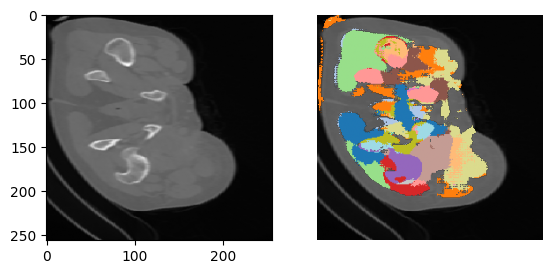

In [16]:
# VISUAL TESTING

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
image_test = data_test[2]
label_test = test_model(image_test.unsqueeze(0).to(device))
pred_test = torch.argmax(label_test, dim=1)
plot_slice_seg(image_test.squeeze(), pred_test.squeeze().cpu().numpy())

In [17]:
test_loader = DataLoader(data_test, batch_size=1, shuffle=False)

predictions = []

for image in test_loader :
    image = image.to(device=device)

    output = test_model(image)

    pred = torch.argmax(output, dim=1)
    predictions.append(pred.cpu().numpy())

predictions = np.array(predictions)
print(np.unique(predictions))
df = pd.DataFrame(predictions.reshape((predictions.shape[0], -1))).T

df.index = [f"Pixel {i}" for i in df.index]

df.columns = [f"{col}.png" for col in df.columns]

df.to_csv("submission.csv")

[ 0  3  4  5  6  7  8  9 10 11 12 13 14 16 17 18 19 20 21 22 23 24 27 28
 29 30 31 32 33 34 35 36 37 38 39 41 42 43 44 45 46 47 48 49 50 51 52 53
 54]


In [18]:
import torch.nn.functional as F

k = 1  # On prend les 3 classes les plus probables

valid_loader = DataLoader(valid_ds, batch_size=1, shuffle=False)
true_masks = []
predictions = []

for image, mask in valid_loader:
    true_masks.extend(mask.cpu().numpy())
    image = image.to(device=device)
    mask = mask.to(device=device)

    output = test_model(image)  # Output: (batch_size, num_classes, H, W)

    # Appliquer softmax pour convertir en probabilités
    probs = F.softmax(output, dim=1)

    # Sélectionner les Top-K classes avec leurs probabilités
    topk_probs, topk_indices = torch.topk(probs, k=k, dim=1)

    # Normalisation des probabilités pour assurer une somme = 1
    topk_probs = topk_probs / topk_probs.sum(dim=1, keepdim=True)

    # Reshape to (batch_size * H * W, top_k) for multinomial
    topk_probs_reshaped = topk_probs.reshape(-1, k)

    # Perform multinomial sampling
    sampled_indices = torch.multinomial(topk_probs_reshaped, num_samples=1).squeeze(-1)

    # Reshape topk_indices to (batch_size * H * W, top_k) for gather
    topk_indices_reshaped = topk_indices.reshape(-1, k)

    # Gather from the topk_indices based on the sampled index
    pred = torch.gather(topk_indices_reshaped, -1, sampled_indices.unsqueeze(-1)).squeeze(-1)

    # Reshape back to original dimensions (batch_size, H, W)
    pred = pred.reshape(output.shape[0], output.shape[2], output.shape[3])

    predictions.extend(pred.squeeze().cpu().numpy())

predictions = pd.DataFrame(np.array(predictions).reshape((-1, 256 * 256)))
valid = pd.DataFrame(np.array(true_masks).reshape((-1, 256 * 256)))

score = dice_pandas(valid, predictions)
print(score)

0.17522162713398415


/tmp/ipykernel_10199/516842608.py:28: RuntimeWarning: Mean of empty slice
  cls_dices = np.nanmean(final, axis=0)


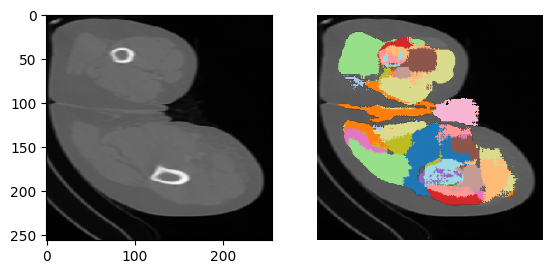

In [19]:
# VISUAL TESTING
image_test = data_test[4]
label_test = test_model(image_test.unsqueeze(0).to(device))
pred_test = torch.argmax(label_test, dim=1)
plot_slice_seg(image_test.squeeze(), pred_test.squeeze().cpu().numpy())